In [24]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

/var/folders/rv/hkq2td3j4dsgn33czsdmly6h0000gn/T/ipykernel_31749/4274747166.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2024['icu_not_vented'] = (


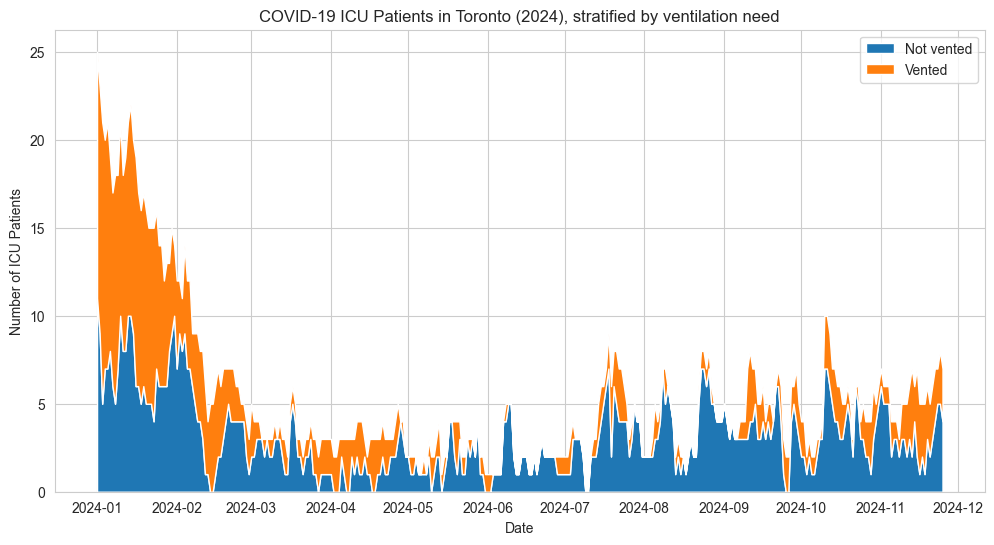

In [ ]:
#Link to the dataset: https://data.ontario.ca/dataset/covid-19-cases-in-hospital-and-icu-by-ontario-health-region/resource/e760480e-1f95-4634-a923-98161cfb02fa

#Read the datafile
data = pd.read_csv("/Users/batukaya/DSI/visualization/02_activities/assignments/Assignment-3/region_hospital_icu_covid_data.csv")
#Drop rows with missing values
data = data.dropna()
#Ensure data type is numeric
data['icu_current_covid'] = pd.to_numeric(data['icu_current_covid'], errors='coerce')
data['icu_current_covid_vented'] = pd.to_numeric(data['icu_current_covid_vented'], errors='coerce')
#Create df with data from 2024

data['date'] = pd.to_datetime(data['date'])
data_2024 = data[data['date'].dt.year == 2024]
#Create new variable to calculate the # of ICU patients NOT on ventilatiom
data_2024['icu_not_vented'] = (
    data_2024['icu_current_covid']
    - data_2024['icu_current_covid_vented']
)

#Only look at the trends in Toronto
region = 'TORONTO'
df = data_2024[data_2024['oh_region'] == region]

#Create the plot
plt.figure(figsize=(12,6))

plt.stackplot(
    df['date'],
    df['icu_not_vented'],
    df['icu_current_covid_vented'],
    labels = ['Not vented', 'Vented']
)
plt.title('COVID-19 ICU Patients in Toronto (2024), stratified by ventilation need')
plt.xlabel('Date')
plt.ylabel('Number of ICU Patients')
plt.legend(loc='upper right')